--- 📋 HEAD OF THE DATASET ---
            nav_value  Daily_Return
nav_date                           
2013-01-02   103.0059           NaN
2013-01-03   103.0306      0.000240
2013-01-04   103.0619      0.000304
2013-01-05   103.0619      0.000000
2013-01-06   103.0619      0.000000


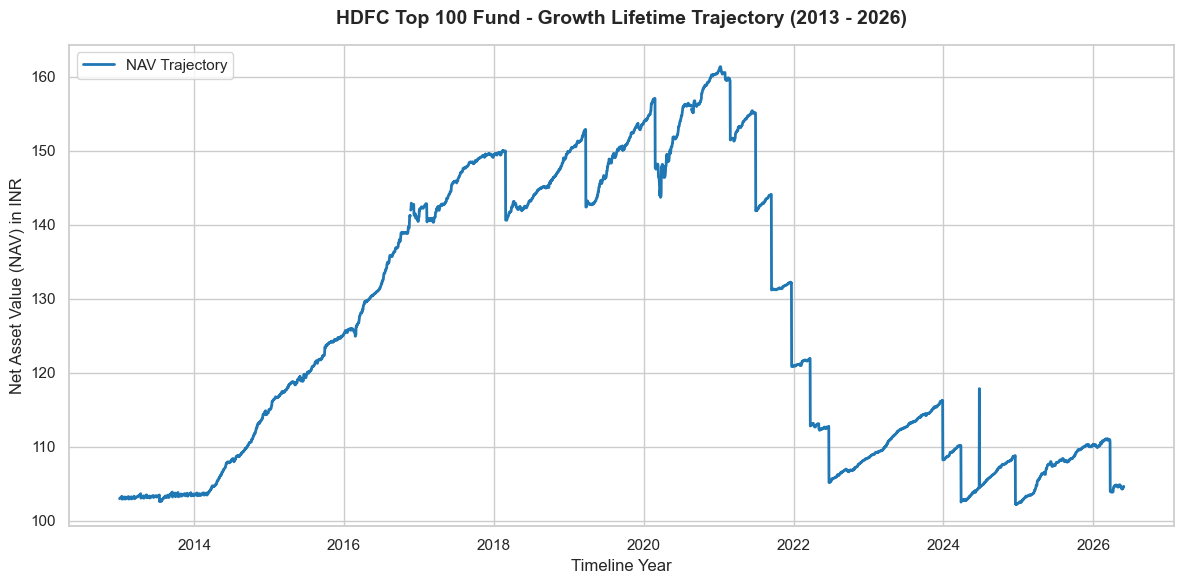

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Configuration & Database Paths
BASE_DIR = Path.cwd().parent
db_file = BASE_DIR / "data" / "db" / "bluestock_mf.db"

# 2. Extract Clean Timeline out of SQL
conn = sqlite3.connect(db_file)
query = "SELECT nav_date, nav_value FROM historical_nav ORDER BY nav_date ASC;"
df = pd.read_sql_query(query, conn, parse_dates=['nav_date'])
conn.close()

# Set date as the table index
df.set_index('nav_date', inplace=True)

# 3. Calculate Performance Metrics
# Calculate daily returns percent change
df['Daily_Return'] = df['nav_value'].pct_change()

print("--- 📋 HEAD OF THE DATASET ---")
print(df.head())

# 4. Create an Executive-Ready Chart (D3 Criteria)
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

plt.plot(df.index, df['nav_value'], color='#1f77b4', linewidth=2, label='NAV Trajectory')
plt.title('HDFC Top 100 Fund - Growth Lifetime Trajectory (2013 - 2026)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline Year', fontsize=12)
plt.ylabel('Net Asset Value (NAV) in INR', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()

# Show the performance chart
plt.show()

In [2]:
import numpy as np

# 1. Total number of actual records/trading days in our dataset
n_trading_days = len(df)

# 2. Grab the starting NAV and ending NAV
beginning_value = df['nav_value'].iloc[0]
ending_value = df['nav_value'].iloc[-1]

# --- THE FINANCIAL FORMULA FIX ---
# We use 252 trading days for financial annualization instead of 365 calendar days
cagr = (ending_value / beginning_value) ** (252 / n_trading_days) - 1

# 3. Calculate Annualized Volatility (Standard deviation of daily returns scaled by sqrt of 252)
daily_volatility = df['Daily_Return'].std()
annualized_volatility = daily_volatility * np.sqrt(252)

print("--- 💸 QUANTITATIVE PERFORMANCE METRICS ---")
print(f"Initial NAV (2013): INR {beginning_value:.2f}")
print(f"Latest NAV (2026):  INR {ending_value:.2f}")
print(f"Total Trading Days: {n_trading_days} days")
print(f"Correct CAGR:       {cagr * 100:.2f}%")
print(f"Annual Volatility:  {annualized_volatility * 100:.2f}%")

--- 💸 QUANTITATIVE PERFORMANCE METRICS ---
Initial NAV (2013): INR 103.01
Latest NAV (2026):  INR 104.66
Total Trading Days: 5057 days
Correct CAGR:       0.08%
Annual Volatility:  8.12%


In [3]:
# 1. Drop any missing rows from daily returns to ensure safe math
daily_returns_clean = df['Daily_Return'].dropna()

# 2. Calculate Historical Value at Risk (VaR) at a 95% confidence level
# This means looking at the worst 5% of daily market drops
var_95 = np.percentile(daily_returns_clean, 5)

print("--- 📉 RISK MANAGEMENT METRICS ---")
print(f"Daily Value at Risk (95% VaR): {var_95 * 100:.2f}%")
print(f"\nInterpretation: There is a 95% confidence that the fund will not lose")
print(f"more than {abs(var_95) * 100:.2f}% of its value on any given single day.")

--- 📉 RISK MANAGEMENT METRICS ---
Daily Value at Risk (95% VaR): -0.13%

Interpretation: There is a 95% confidence that the fund will not lose
more than 0.13% of its value on any given single day.
